<a href="https://colab.research.google.com/github/shreyashpc/kaggle_w11/blob/main/Copy_of_notebookb193643044.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

dlp_26_t_2_week_11_assignment_path = kagglehub.competition_download('dlp-26-t-2-week-11-assignment')

print('Data source import complete.')


100%|██████████| 1.00G/1.00G [00:09<00:00, 115MB/s]

Extracting files...


Data source import complete.


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
# import os

# for root, dirs, files in os.walk("/kaggle/input"):
#     level = root.replace("/kaggle/input", "").count(os.sep)
#     indent = "  " * level
#     print(f"{indent}{os.path.basename(root)}/")

#     if level < 2:
#         for file in files[:10]:
#             print(f"{indent}  {file}")

In [ ]:
dlp_26_t_2_week_11_assignment_path

'/root/.cache/kagglehub/competitions/dlp-26-t-2-week-11-assignment'

In [ ]:
from pathlib import Path

BASE = Path(dlp_26_t_2_week_11_assignment_path + "/competition-data/competition-data")

for split in ["training", "validation", "testing"]:
    split_path = BASE / split

    print(f"\n{'='*50}")
    print(f"{split.upper()}")
    print(f"{'='*50}")

    if not split_path.exists():
        print("❌ Folder not found")
        continue

    for folder in split_path.iterdir():
        if folder.is_dir():
            files = sorted([f for f in folder.iterdir() if f.is_file()])
            print(f"{folder.name}: {len(files)} files")
            print("First 5:", [f.name for f in files[:5]])


TRAINING
depths: 6686 files
First 5: ['10012003.png', '10012004.png', '10022005.png', '10022006.png', '10032007.png']
images: 6686 files
First 5: ['10012003.png', '10012004.png', '10022005.png', '10022006.png', '10032007.png']

VALIDATION
depths: 836 files
First 5: ['01.png', '02.png', '10002001.png', '10002002.png', '100201.png']
images: 836 files
First 5: ['01.png', '02.png', '10002001.png', '10002002.png', '100201.png']

TESTING
images: 836 files
First 5: ['10052011.png', '10052012.png', '10152031.png', '10152032.png', '10252051.png']


In [ ]:
from pathlib import Path
import os

# ============================================================
# ENVIRONMENT CONFIGURATION
# Change ONLY this line:
# "kaggle" or "colab"
# ============================================================

ENV = "colab"


# ============================================================
# PLATFORM-SPECIFIC ROOT PATHS
# ============================================================

if ENV == "kaggle":

    # Competition root
    COMPETITION_DIR = Path(
        "/kaggle/input/competitions/"
        "dlp-26-t-2-week-11-assignment"
    )

    # Dataset is nested inside competition-data/competition-data
    DATA_DIR = (
        COMPETITION_DIR
        / "competition-data"
        / "competition-data"
    )

    # Kaggle working directory
    WORK_DIR = Path("/kaggle/working")


elif ENV == "colab":

    # Competition root
    COMPETITION_DIR = Path(
        dlp_26_t_2_week_11_assignment_path
    )

    # Dataset is nested inside competition-data/competition-data
    DATA_DIR = (
        COMPETITION_DIR
        / "competition-data"
        / "competition-data"
    )

    # Colab working directory
    WORK_DIR = Path("/content")


else:
    raise ValueError(
        "ENV must be either 'kaggle' or 'colab'"
    )


# ============================================================
# OFFICIAL SUBMISSION SCRIPT
# ============================================================

IMG2CSV_PATH = (
    COMPETITION_DIR / "imgs2csv.py"
)


# ============================================================
# DATASET PATHS
# ============================================================

TRAIN_IMG_DIR = (
    DATA_DIR / "training" / "images"
)

TRAIN_DEPTH_DIR = (
    DATA_DIR / "training" / "depths"
)

VAL_IMG_DIR = (
    DATA_DIR / "validation" / "images"
)

VAL_DEPTH_DIR = (
    DATA_DIR / "validation" / "depths"
)

TEST_IMG_DIR = (
    DATA_DIR / "testing" / "images"
)


# ============================================================
# WORKING / OUTPUT PATHS
# ============================================================

BASELINE_CHECKPOINT = (
    WORK_DIR / "baseline_best.pth"
)

BEST_CHECKPOINT = (
    WORK_DIR / "best_depth_model.pth"
)

# IMPORTANT:
# imgs2csv.py expects this exact relative folder:
# "data/sample_solution"
PREDICTION_DIR = (
    WORK_DIR / "data" / "sample_solution"
)

PREDICTIONS_CSV = (
    WORK_DIR / "predictions.csv"
)

SUBMISSION_PATH = (
    WORK_DIR / "submission.csv"
)


# ============================================================
# CREATE OUTPUT DIRECTORIES
# ============================================================

WORK_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PREDICTION_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# VERIFY PATHS
# ============================================================

print("=" * 70)
print("ENVIRONMENT CONFIGURATION")
print("=" * 70)

print("Environment       :", ENV)
print("Competition dir   :", COMPETITION_DIR)
print("Dataset dir       :", DATA_DIR)
print("Work dir          :", WORK_DIR)
print("imgs2csv.py       :", IMG2CSV_PATH)

print("\n" + "=" * 70)
print("DATASET")
print("=" * 70)

print(
    "Train images      :",
    TRAIN_IMG_DIR.exists(),
    TRAIN_IMG_DIR
)

print(
    "Train depths      :",
    TRAIN_DEPTH_DIR.exists(),
    TRAIN_DEPTH_DIR
)

print(
    "Validation images :",
    VAL_IMG_DIR.exists(),
    VAL_IMG_DIR
)

print(
    "Validation depths :",
    VAL_DEPTH_DIR.exists(),
    VAL_DEPTH_DIR
)

print(
    "Test images       :",
    TEST_IMG_DIR.exists(),
    TEST_IMG_DIR
)

print("\n" + "=" * 70)
print("SUBMISSION")
print("=" * 70)

print(
    "imgs2csv.py       :",
    IMG2CSV_PATH.exists(),
    IMG2CSV_PATH
)

print(
    "Prediction dir    :",
    PREDICTION_DIR,
    PREDICTION_DIR.exists()
)

ENVIRONMENT CONFIGURATION
Environment       : colab
Competition dir   : /root/.cache/kagglehub/competitions/dlp-26-t-2-week-11-assignment
Dataset dir       : /root/.cache/kagglehub/competitions/dlp-26-t-2-week-11-assignment/competition-data/competition-data
Work dir          : /content
imgs2csv.py       : /root/.cache/kagglehub/competitions/dlp-26-t-2-week-11-assignment/imgs2csv.py

DATASET
Train images      : True /root/.cache/kagglehub/competitions/dlp-26-t-2-week-11-assignment/competition-data/competition-data/training/images
Train depths      : True /root/.cache/kagglehub/competitions/dlp-26-t-2-week-11-assignment/competition-data/competition-data/training/depths
Validation images : True /root/.cache/kagglehub/competitions/dlp-26-t-2-week-11-assignment/competition-data/competition-data/validation/images
Validation depths : True /root/.cache/kagglehub/competitions/dlp-26-t-2-week-11-assignment/competition-data/competition-data/validation/depths
Test images       : True /root/.cache/

In [ ]:
# train_images = sorted((BASE / "training" / "images").iterdir())
# train_depths = sorted((BASE / "training" / "depths").iterdir())

# print("First 10 image filenames:")
# for f in train_images[:10]:
#     print(f.name)

# print("\nFirst 10 depth filenames:")
# for f in train_depths[:10]:
#     print(f.name)

In [ ]:
# from PIL import Image
# import numpy as np
# import matplotlib.pyplot as plt

# img_path = train_images[0]
# depth_path = train_depths[0]

# rgb = np.array(Image.open(img_path))
# depth = np.array(Image.open(depth_path))

# print("RGB")
# print("  Path :", img_path)
# print("  Shape:", rgb.shape)
# print("  Dtype:", rgb.dtype)
# print("  Min  :", rgb.min())
# print("  Max  :", rgb.max())

# print("\nDepth")
# print("  Path :", depth_path)
# print("  Shape:", depth.shape)
# print("  Dtype:", depth.dtype)
# print("  Min  :", depth.min())
# print("  Max  :", depth.max())

In [ ]:
# plt.figure(figsize=(12, 5))

# plt.subplot(1, 2, 1)
# plt.imshow(rgb)
# plt.title("RGB Image")
# plt.axis("off")

# plt.subplot(1, 2, 2)
# plt.imshow(depth, cmap="turbo")
# plt.title("Ground Truth Depth")
# plt.axis("off")

# plt.show()

In [ ]:
# from pathlib import Path
# import numpy as np
# from PIL import Image

# train_depth_dir = BASE / "training" / "depths"

# depth_mins = []
# depth_maxs = []
# depth_means = []
# depth_stds = []
# depth_zeros = []

# for path in train_depth_dir.iterdir():
#     depth = np.array(Image.open(path))

#     depth_mins.append(depth.min())
#     depth_maxs.append(depth.max())
#     depth_means.append(depth.mean())
#     depth_stds.append(depth.std())
#     depth_zeros.append(np.mean(depth == 0))

# print("Depth statistics across training set")
# print("-" * 50)

# print(f"Minimum depth value:")
# print(f"  min = {np.min(depth_mins):.2f}")
# print(f"  max = {np.max(depth_mins):.2f}")
# print(f"  mean = {np.mean(depth_mins):.2f}")

# print(f"\nMaximum depth value:")
# print(f"  min = {np.min(depth_maxs):.2f}")
# print(f"  max = {np.max(depth_maxs):.2f}")
# print(f"  mean = {np.mean(depth_maxs):.2f}")

# print(f"\nMean depth:")
# print(f"  min = {np.min(depth_means):.2f}")
# print(f"  max = {np.max(depth_means):.2f}")
# print(f"  mean = {np.mean(depth_means):.2f}")

# print(f"\nDepth standard deviation:")
# print(f"  min = {np.min(depth_stds):.2f}")
# print(f"  max = {np.max(depth_stds):.2f}")
# print(f"  mean = {np.mean(depth_stds):.2f}")

# print(f"\nPercentage of zero-depth pixels:")
# print(f"  min = {np.min(depth_zeros)*100:.2f}%")
# print(f"  max = {np.max(depth_zeros)*100:.2f}%")
# print(f"  mean = {np.mean(depth_zeros)*100:.2f}%")

In [ ]:
# train_img_dir = BASE / "training" / "images"

# rgb_means = []
# rgb_stds = []
# rgb_mins = []
# rgb_maxs = []

# for path in train_img_dir.iterdir():
#     img = np.array(Image.open(path)).astype(np.float32)

#     rgb_means.append(img.mean())
#     rgb_stds.append(img.std())
#     rgb_mins.append(img.min())
#     rgb_maxs.append(img.max())

# print("RGB statistics across training set")
# print("-" * 50)

# print(f"Mean pixel intensity:")
# print(f"  min  = {np.min(rgb_means):.2f}")
# print(f"  max  = {np.max(rgb_means):.2f}")
# print(f"  mean = {np.mean(rgb_means):.2f}")

# print(f"\nPixel standard deviation:")
# print(f"  min  = {np.min(rgb_stds):.2f}")
# print(f"  max  = {np.max(rgb_stds):.2f}")
# print(f"  mean = {np.mean(rgb_stds):.2f}")

# print(f"\nMaximum pixel value:")
# print(f"  min  = {np.min(rgb_maxs):.2f}")
# print(f"  max  = {np.max(rgb_maxs):.2f}")

In [ ]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(8, 5))
# plt.hist(rgb_means, bins=50)
# plt.xlabel("Mean RGB intensity")
# plt.ylabel("Number of images")
# plt.title("Training RGB Brightness Distribution")
# plt.show()

In [ ]:
# plt.figure(figsize=(8, 5))
# plt.hist(depth_means, bins=50)
# plt.xlabel("Mean depth value")
# plt.ylabel("Number of images")
# plt.title("Training Depth Distribution")
# plt.show()

In [ ]:
# import random

# random.seed(42)

# sample_paths = random.sample(train_images, 6)

# plt.figure(figsize=(15, 9))

# for i, img_path in enumerate(sample_paths):
#     depth_path = train_depth_dir / img_path.name

#     rgb = np.array(Image.open(img_path))
#     depth = np.array(Image.open(depth_path))

#     plt.subplot(3, 4, 2*i + 1)
#     plt.imshow(rgb)
#     plt.title(f"RGB: {img_path.name}")
#     plt.axis("off")

#     plt.subplot(3, 4, 2*i + 2)
#     plt.imshow(depth, cmap="turbo")
#     plt.title("Ground Truth Depth")
#     plt.axis("off")

# plt.tight_layout()
# plt.show()

In [ ]:
# # Inspect depth value distribution and zero pixels

# sample_depth_values = {}

# for path in train_depths[:10]:
#     depth = np.array(Image.open(path))

#     unique, counts = np.unique(depth, return_counts=True)

#     print(f"\n{path.name}")
#     print(f"Shape: {depth.shape}")
#     print(f"Min: {depth.min()}, Max: {depth.max()}")
#     print(f"Mean: {depth.mean():.2f}")
#     print(f"Zero pixels: {(depth == 0).sum()} "
#           f"({100 * np.mean(depth == 0):.2f}%)")
#     print(f"Unique values: {len(unique)}")
#     print(f"First 20 unique values: {unique[:20]}")

In [ ]:
# zero_stats = []

# for path in train_depths:
#     depth = np.array(Image.open(path))
#     zero_pct = 100 * np.mean(depth == 0)
#     zero_stats.append((zero_pct, path.name))

# zero_stats = sorted(zero_stats, reverse=True)

# print("Top 20 images by percentage of zero-depth pixels:")
# print("-" * 60)

# for pct, name in zero_stats[:20]:
#     print(f"{name:20s} {pct:6.2f}%")

In [ ]:
# worst_name = zero_stats[0][1]

# rgb = np.array(
#     Image.open(BASE / "training" / "images" / worst_name)
# )

# depth = np.array(
#     Image.open(BASE / "training" / "depths" / worst_name)
# )

# plt.figure(figsize=(12, 5))

# plt.subplot(1, 2, 1)
# plt.imshow(rgb)
# plt.title(f"RGB - {worst_name}")
# plt.axis("off")

# plt.subplot(1, 2, 2)
# plt.imshow(depth, cmap="turbo")
# plt.title(
#     f"Depth - {worst_name}\n"
#     f"Zero pixels: {100*np.mean(depth==0):.2f}%"
# )
# plt.axis("off")

# plt.show()

In [ ]:
# val_depth_dir = BASE / "validation" / "depths"

# val_means = []
# val_mins = []
# val_maxs = []

# for path in val_depth_dir.iterdir():
#     depth = np.array(Image.open(path))

#     val_means.append(depth.mean())
#     val_mins.append(depth.min())
#     val_maxs.append(depth.max())

# print("VALIDATION DEPTH STATISTICS")
# print("-" * 50)

# print(f"Mean depth:")
# print(f"  min  = {np.min(val_means):.2f}")
# print(f"  max  = {np.max(val_means):.2f}")
# print(f"  mean = {np.mean(val_means):.2f}")

# print(f"\nMinimum depth:")
# print(f"  min  = {np.min(val_mins):.2f}")
# print(f"  max  = {np.max(val_mins):.2f}")

# print(f"\nMaximum depth:")
# print(f"  min  = {np.min(val_maxs):.2f}")
# print(f"  max  = {np.max(val_maxs):.2f}")

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import numpy as np
from PIL import Image
from pathlib import Path

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [116]:
class DepthDataset(Dataset):

    def __init__(
        self,
        image_dir,
        depth_dir=None,
        gamma=None
    ):
        self.image_dir = Path(image_dir)

        self.depth_dir = (
            Path(depth_dir)
            if depth_dir is not None
            else None
        )

        self.gamma = gamma

        self.image_paths = sorted(
            [
                p for p in self.image_dir.iterdir()
                if p.suffix.lower() == ".png"
            ]
        )

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        image_path = self.image_paths[idx]

        # --------------------------------------------------
        # RGB
        # --------------------------------------------------

        image = np.array(
            Image.open(image_path).convert("RGB"),
            dtype=np.float32
        )

        image /= 255.0

        # Low-light enhancement
        if self.gamma is not None:
            image = np.power(
                np.clip(image, 0.0, 1.0),
                self.gamma
            )

        image = torch.from_numpy(
            image
        ).permute(2, 0, 1).float()

        # --------------------------------------------------
        # DEPTH
        # --------------------------------------------------

        if self.depth_dir is not None:

            depth_path = (
                self.depth_dir /
                image_path.name
            )

            depth = np.array(
                Image.open(depth_path),
                dtype=np.float32
            )

            depth /= 255.0

            depth = torch.from_numpy(
                depth
            ).unsqueeze(0).float()

            return image, depth

        # --------------------------------------------------
        # TEST
        # --------------------------------------------------

        return image, image_path.name

In [117]:
# ============================================================
# EXPERIMENT 2 DATASETS
# ============================================================

# IMPORTANT:
# Use EXACTLY the same preprocessing for
# train / validation / test.

GAMMA = 0.5

train_dataset = DepthDataset(
    TRAIN_IMG_DIR,
    TRAIN_DEPTH_DIR,
    gamma=GAMMA
)

val_dataset = DepthDataset(
    VAL_IMG_DIR,
    VAL_DEPTH_DIR,
    gamma=GAMMA
)

test_dataset = DepthDataset(
    TEST_IMG_DIR,
    depth_dir=None,
    gamma=GAMMA
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

print("\nPreprocessing:")
print("Gamma:", GAMMA)

Train: 6686
Validation: 836
Test: 836

Preprocessing:
Gamma: 0.5


In [ ]:
# image, depth = train_dataset[0]

# print("Image:")
# print("Shape:", image.shape)
# print("Dtype:", image.dtype)
# print("Min:", image.min().item())
# print("Max:", image.max().item())

# print("\nDepth:")
# print("Shape:", depth.shape)
# print("Dtype:", depth.dtype)
# print("Min:", depth.min().item())
# print("Max:", depth.max().item())

In [118]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    drop_last=False
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 418
Val batches: 53
Test batches: 53


In [ ]:
images, depths = next(iter(train_loader))

print("Batch images:", images.shape)
print("Batch depths:", depths.shape)

Batch images: torch.Size([16, 3, 256, 256])
Batch depths: torch.Size([16, 1, 256, 256])


In [ ]:
import torchvision

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

Torch: 2.11.0+cu128
Torchvision: 0.26.0+cu128


In [ ]:
from torchvision.models import resnet18, ResNet18_Weights

print("torchvision ResNet18 available")

torchvision ResNet18 available


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18, ResNet18_Weights


class ResNet18Encoder(nn.Module):

    def __init__(self):
        super().__init__()

        backbone = resnet18(weights=ResNet18_Weights.DEFAULT)

        self.conv1 = backbone.conv1
        self.bn1 = backbone.bn1
        self.relu = backbone.relu
        self.maxpool = backbone.maxpool

        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

    def forward(self, x):

        # 256 → 128
        x0 = self.relu(self.bn1(self.conv1(x)))

        # 128 → 64
        x1 = self.layer1(self.maxpool(x0))

        # 64 → 32
        x2 = self.layer2(x1)

        # 32 → 16
        x3 = self.layer3(x2)

        # 16 → 8
        x4 = self.layer4(x3)

        return x0, x1, x2, x3, x4

In [ ]:
class DecoderBlock(nn.Module):

    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels + skip_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x, skip):

        x = F.interpolate(
            x,
            size=skip.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        x = torch.cat([x, skip], dim=1)

        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))

        return x

In [ ]:
class DepthUNetResNet18(nn.Module):

    def __init__(self):
        super().__init__()

        self.register_buffer(
            "mean",
            torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        )

        self.register_buffer(
            "std",
            torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        )

        self.encoder = ResNet18Encoder()

        self.dec4 = DecoderBlock(512, 256, 256)
        self.dec3 = DecoderBlock(256, 128, 128)
        self.dec2 = DecoderBlock(128, 64, 64)
        self.dec1 = DecoderBlock(64, 64, 64)

        self.final = nn.Sequential(
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 1, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):

        # ImageNet normalization
        x = (x - self.mean) / self.std

        x0, x1, x2, x3, x4 = self.encoder(x)

        x = self.dec4(x4, x3)
        x = self.dec3(x, x2)
        x = self.dec2(x, x1)
        x = self.dec1(x, x0)

        x = F.interpolate(
            x,
            size=(256, 256),
            mode="bilinear",
            align_corners=False
        )

        x = self.final(x)

        return x

In [ ]:
model = DepthUNetResNet18().to(device)

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 177MB/s]


DepthUNetResNet18(
  (encoder): ResNet18Encoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, aff

In [ ]:
# total_params = sum(
#     p.numel() for p in model.parameters()
# )

# trainable_params = sum(
#     p.numel() for p in model.parameters()
#     if p.requires_grad
# )

# print(f"Total parameters:     {total_params:,}")
# print(f"Trainable parameters: {trainable_params:,}")

In [ ]:
# images, depths = next(iter(train_loader))

# images = images.to(device)

# with torch.no_grad():
#     predictions = model(images)

# print("Input shape:      ", images.shape)
# print("Prediction shape: ", predictions.shape)
# print("Prediction min:   ", predictions.min().item())
# print("Prediction max:   ", predictions.max().item())

In [ ]:
# criterion = nn.MSELoss()

In [119]:
def competition_depth_loss(pred, target):
    """
    Differentiable approximation of the competition metric.

    Competition pipeline:
        prediction
        -> resize 128x128
        -> per-image min-max normalization
        -> compare against GT at 128x128
    """

    # --------------------------------------------------
    # Downsample prediction and target
    # --------------------------------------------------

    pred_128 = F.interpolate(
        pred,
        size=(128, 128),
        mode="bilinear",
        align_corners=False
    )

    target_128 = F.interpolate(
        target,
        size=(128, 128),
        mode="bilinear",
        align_corners=False
    )

    # --------------------------------------------------
    # Per-image min-max normalization
    # --------------------------------------------------

    B = pred_128.shape[0]

    pred_flat = pred_128.view(B, -1)

    pred_min = pred_flat.min(
        dim=1,
        keepdim=True
    )[0]

    pred_max = pred_flat.max(
        dim=1,
        keepdim=True
    )[0]

    pred_norm = (
        pred_flat - pred_min
    ) / (
        pred_max - pred_min + 1e-6
    )

    pred_norm = pred_norm.view(
        B, 1, 128, 128
    )

    # --------------------------------------------------
    # Competition-aligned MSE
    # --------------------------------------------------

    loss = torch.mean(
        (pred_norm - target_128) ** 2
    )

    return loss

In [120]:
def depth_gradient_loss(pred, target):

    # Horizontal gradients
    pred_dx = (
        pred[:, :, :, 1:]
        - pred[:, :, :, :-1]
    )

    target_dx = (
        target[:, :, :, 1:]
        - target[:, :, :, :-1]
    )

    # Vertical gradients
    pred_dy = (
        pred[:, :, 1:, :]
        - pred[:, :, :-1, :]
    )

    target_dy = (
        target[:, :, 1:, :]
        - target[:, :, :-1, :]
    )

    loss_x = torch.mean(
        torch.abs(pred_dx - target_dx)
    )

    loss_y = torch.mean(
        torch.abs(pred_dy - target_dy)
    )

    return loss_x + loss_y

In [121]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print(
    "Optimizer ready:",
    optimizer
)

Optimizer ready: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)


In [ ]:
def calculate_rmse(model, loader):

    model.eval()

    squared_error = 0.0
    num_pixels = 0

    with torch.no_grad():

        for images, depths in loader:

            images = images.to(device, non_blocking=True)
            depths = depths.to(device, non_blocking=True)

            predictions = model(images)

            squared_error += torch.sum(
                (predictions - depths) ** 2
            ).item()

            num_pixels += depths.numel()

    mse = squared_error / num_pixels
    rmse = np.sqrt(mse)

    return rmse

In [ ]:
# def train_one_epoch(model, loader, criterion, optimizer):

#     model.train()

#     running_loss = 0.0

#     for images, depths in loader:

#         images = images.to(device, non_blocking=True)
#         depths = depths.to(device, non_blocking=True)

#         optimizer.zero_grad()

#         predictions = model(images)

#         loss = criterion(predictions, depths)

#         loss.backward()

#         optimizer.step()

#         running_loss += loss.item()

#     return running_loss / len(loader)

In [122]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    competition_weight=1.0,
    gradient_weight=0.05
):

    model.train()

    running_loss = 0.0
    running_comp_loss = 0.0
    running_grad_loss = 0.0

    for images, depths in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        depths = depths.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        predictions = model(images)

        # Competition-aligned loss
        comp_loss = competition_depth_loss(
            predictions,
            depths
        )

        # Structural depth loss
        grad_loss = depth_gradient_loss(
            predictions,
            depths
        )

        loss = (
            competition_weight * comp_loss
            +
            gradient_weight * grad_loss
        )

        loss.backward()

        # Prevent occasional exploding gradients
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_loss += loss.item()
        running_comp_loss += comp_loss.item()
        running_grad_loss += grad_loss.item()

    n = len(loader)

    return (
        running_loss / n,
        running_comp_loss / n,
        running_grad_loss / n
    )

In [ ]:
EPOCHS = 5

history = []

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_rmse = calculate_rmse(
        model,
        val_loader
    )

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_rmse": val_rmse
    })

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.6f} "
        f"Val RMSE: {val_rmse:.6f}"
    )

Epoch [1/5] Train Loss: 0.012499 Val RMSE: 0.094093
Epoch [2/5] Train Loss: 0.007761 Val RMSE: 0.086830
Epoch [3/5] Train Loss: 0.005587 Val RMSE: 0.084381
Epoch [4/5] Train Loss: 0.004066 Val RMSE: 0.084795
Epoch [5/5] Train Loss: 0.003397 Val RMSE: 0.079305


In [ ]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "val_rmse": 0.078617,
        "epoch": 5,
    },
    "/content/baseline_best.pth"
)

print("Saved baseline checkpoint.")

Saved baseline checkpoint.


In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# import torch

# model.eval()

# images, depths = next(iter(val_loader))

# with torch.no_grad():
#     predictions = model(images.to(device)).cpu()

# images = images.cpu()
# depths = depths.cpu()

# n = 4

# plt.figure(figsize=(16, 12))

# for i in range(n):

#     # RGB
#     plt.subplot(n, 4, i*4 + 1)
#     rgb = images[i].permute(1, 2, 0).numpy()
#     plt.imshow(rgb)
#     plt.title("RGB Input")
#     plt.axis("off")

#     # Ground truth
#     plt.subplot(n, 4, i*4 + 2)
#     gt = depths[i, 0].numpy()
#     plt.imshow(gt, cmap="turbo")
#     plt.title("Ground Truth")
#     plt.axis("off")

#     # Prediction
#     plt.subplot(n, 4, i*4 + 3)
#     pred = predictions[i, 0].numpy()
#     plt.imshow(pred, cmap="turbo")
#     plt.title("Prediction")
#     plt.axis("off")

#     # Error
#     plt.subplot(n, 4, i*4 + 4)
#     error = np.abs(gt - pred)
#     plt.imshow(error, cmap="hot")
#     plt.title(f"Absolute Error\nMean={error.mean():.4f}")
#     plt.axis("off")

# plt.tight_layout()
# plt.show()

# Experiment 1 — Gamma-enhanced input

In [ ]:
def gamma_correct(image, gamma=0.5):
    return torch.clamp(image, 0, 1) ** gamma

In [ ]:
# images, depths = next(iter(val_loader))

# original = images[:4]
# enhanced = gamma_correct(original, gamma=0.5)

# plt.figure(figsize=(12, 8))

# for i in range(4):

#     plt.subplot(2, 4, i + 1)
#     plt.imshow(original[i].permute(1, 2, 0).numpy())
#     plt.title("Original")
#     plt.axis("off")

#     plt.subplot(2, 4, i + 5)
#     plt.imshow(enhanced[i].permute(1, 2, 0).numpy())
#     plt.title("Gamma 0.5")
#     plt.axis("off")

# plt.tight_layout()
# plt.show()

# Predictions

In [ ]:
# import os
# from pathlib import Path

# prediction_dir = Path("/kaggle/working/test_predictions")
# prediction_dir.mkdir(parents=True, exist_ok=True)

# print("Prediction directory:", prediction_dir)

In [ ]:
# model.eval()

# with torch.no_grad():

#     for images, filenames in test_loader:

#         images = images.to(device, non_blocking=True)

#         predictions = model(images)

#         predictions = predictions.squeeze(1).cpu().numpy()

#         for pred, filename in zip(predictions, filenames):

#             # Model output is [0, 1]
#             pred = np.clip(pred, 0, 1)

#             # Convert to uint8 PNG
#             pred_uint8 = (pred * 255).astype(np.uint8)

#             save_path = prediction_dir / filename

#             Image.fromarray(pred_uint8).save(save_path)

# print("Generated:", len(list(prediction_dir.glob("*.png"))), "prediction images")

In [ ]:
# prediction_files = sorted(prediction_dir.glob("*.png"))

# print("Number of predictions:", len(prediction_files))
# print("First 10:")
# for p in prediction_files[:10]:
#     print(p.name)

In [ ]:
# plt.figure(figsize=(12, 8))

# for i, path in enumerate(prediction_files[:4]):

#     pred = np.array(Image.open(path))

#     plt.subplot(2, 2, i + 1)
#     plt.imshow(pred, cmap="turbo")
#     plt.title(path.name)
#     plt.axis("off")

# plt.tight_layout()
# plt.show()

In [ ]:
# pred_mins = []
# pred_maxs = []
# pred_means = []

# for path in prediction_files:

#     pred = np.array(Image.open(path))

#     pred_mins.append(pred.min())
#     pred_maxs.append(pred.max())
#     pred_means.append(pred.mean())

# print("Prediction statistics")
# print("-" * 40)

# print(f"Min values:  min={min(pred_mins)}, max={max(pred_mins)}")
# print(f"Max values:  min={min(pred_maxs)}, max={max(pred_maxs)}")
# print(f"Mean values: min={min(pred_means):.2f}, max={max(pred_means):.2f}")

In [ ]:
# predictions_folder = "data/sample_solution"
# predictions_csv = "predictions.csv"

In [ ]:
# import shutil
# import os

# submission_input_dir = Path("/kaggle/working/data/sample_solution")
# submission_input_dir.mkdir(parents=True, exist_ok=True)

# for path in prediction_files:
#     shutil.copy2(
#         path,
#         submission_input_dir / path.name
#     )

# print(
#     "Files prepared:",
#     len(list(submission_input_dir.glob("*.png")))
# )

In [ ]:
# script_path = "/kaggle/input/competitions/dlp-26-t-2-week-11-assignment/imgs2csv.py"

# exec(open(script_path).read())

In [ ]:
# import os

# predictions_csv = "/kaggle/working/predictions.csv"
# submission_csv = "/kaggle/working/submission.csv"

# os.replace(predictions_csv, submission_csv)

# print("Created:", submission_csv)

In [ ]:
# pixel_columns = [
#     c for c in submission.columns
#     if c not in ["id", "ImageID"]
# ]

# print(
#     "Number of pixel columns:",
#     len(pixel_columns)
# )

# print(
#     "Pixel range:",
#     submission[pixel_columns].min().min(),
#     "to",
#     submission[pixel_columns].max().max()
# )

In [ ]:
# def competition_style_rmse(model, loader):
#     model.eval()

#     squared_error = 0.0
#     num_pixels = 0

#     with torch.no_grad():

#         for images, depths in loader:

#             images = images.to(device)

#             predictions = model(images)

#             predictions = predictions.squeeze(1).cpu().numpy()
#             depths = depths.squeeze(1).cpu().numpy()

#             for pred, gt in zip(predictions, depths):

#                 # -------------------------------
#                 # Same prediction processing
#                 # -------------------------------

#                 pred = np.clip(pred, 0, 1)

#                 pred = (pred * 255).astype(np.uint8)

#                 pred = cv2.resize(
#                     pred,
#                     (128, 128)
#                 )

#                 pred = pred / 255.0

#                 pred = (
#                     pred - pred.min()
#                 ) / (
#                     pred.max() - pred.min() + 1e-6
#                 )

#                 pred = np.uint8(pred * 255)

#                 # -------------------------------
#                 # Ground truth resized to 128x128
#                 # -------------------------------

#                 gt = (gt * 255).astype(np.uint8)

#                 gt = cv2.resize(
#                     gt,
#                     (128, 128)
#                 )

#                 # -------------------------------
#                 # RMSE on competition scale
#                 # -------------------------------

#                 error = (
#                     pred.astype(np.float32)
#                     - gt.astype(np.float32)
#                 )

#                 squared_error += np.sum(error ** 2)
#                 num_pixels += error.size

#     rmse = np.sqrt(
#         squared_error / num_pixels
#     )

#     return rmse

In [ ]:
# competition_rmse = competition_style_rmse(
#     model,
#     val_loader
# )

# print(
#     f"Competition-style validation RMSE: "
#     f"{competition_rmse:.5f}"
# )

In [ ]:
EPOCHS = 10

In [ ]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [ ]:
best_rmse = float("inf")

for epoch in range(6, 16):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_rmse = calculate_rmse(
        model,
        val_loader
    )

    scheduler.step(val_rmse)

    print(
        f"Epoch [{epoch}/15] "
        f"Train Loss: {train_loss:.6f} "
        f"Val RMSE: {val_rmse:.6f} "
        f"LR: {optimizer.param_groups[0]['lr']:.2e}"
    )

    if val_rmse < best_rmse:
        best_rmse = val_rmse

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_rmse": val_rmse
            },
            "/content/best_depth_model.pth"
        )

        print("  ✓ Saved new best model")

Epoch [6/15] Train Loss: 0.002848 Val RMSE: 0.077649 LR: 1.00e-04
  ✓ Saved new best model
Epoch [7/15] Train Loss: 0.002617 Val RMSE: 0.076775 LR: 1.00e-04
  ✓ Saved new best model
Epoch [8/15] Train Loss: 0.002319 Val RMSE: 0.075657 LR: 1.00e-04
  ✓ Saved new best model
Epoch [9/15] Train Loss: 0.002059 Val RMSE: 0.074204 LR: 1.00e-04
  ✓ Saved new best model
Epoch [10/15] Train Loss: 0.001883 Val RMSE: 0.074940 LR: 1.00e-04
Epoch [11/15] Train Loss: 0.001837 Val RMSE: 0.073299 LR: 1.00e-04
  ✓ Saved new best model
Epoch [12/15] Train Loss: 0.001702 Val RMSE: 0.073906 LR: 1.00e-04
Epoch [13/15] Train Loss: 0.001578 Val RMSE: 0.072523 LR: 1.00e-04
  ✓ Saved new best model
Epoch [14/15] Train Loss: 0.001468 Val RMSE: 0.071651 LR: 1.00e-04
  ✓ Saved new best model
Epoch [15/15] Train Loss: 0.001406 Val RMSE: 0.071423 LR: 1.00e-04
  ✓ Saved new best model


# DEPTH ESTIMATION SCOREBOARD


* Baseline v1
* ResNet18 + U-Net
* 5 epochs
* Val RMSE: 0.078617
* Kaggle:   22.36472


Baseline v2

* ResNet18 + U-Net1
* 5 epochs
* Val RMSE: 0.071529
* Kaggle:   NOT SUBMITTED YET

In [ ]:
current_rmse = calculate_rmse(
    model,
    val_loader
)

print(f"Current model validation RMSE: {current_rmse:.6f}")

In [ ]:
checkpoint = torch.load(
    "/content/best_depth_model.pth",
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print("Checkpoint epoch:", checkpoint["epoch"])
print("Checkpoint RMSE:", checkpoint["val_rmse"])

model.eval()

In [ ]:
loaded_rmse = calculate_rmse(
    model,
    val_loader
)

print(
    f"Loaded model RMSE: {loaded_rmse:.6f}"
)

In [ ]:
from pathlib import Path
from PIL import Image
import numpy as np

prediction_dir = PREDICTION_DIR

prediction_dir.mkdir(
    parents=True,
    exist_ok=True
)

# Clear old predictions
for p in prediction_dir.glob("*.png"):
    p.unlink()

model.eval()

with torch.no_grad():

    for images, filenames in test_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        predictions = model(images)

        predictions = (
            predictions
            .squeeze(1)
            .cpu()
            .numpy()
        )

        for pred, filename in zip(
            predictions,
            filenames
        ):

            pred = np.clip(pred, 0, 1)

            pred_uint8 = (
                pred * 255
            ).round().astype(np.uint8)

            Image.fromarray(
                pred_uint8
            ).save(
                prediction_dir / filename
            )

print(
    "Generated:",
    len(list(prediction_dir.glob("*.png")))
)

In [ ]:
exec(open(IMG2CSV_PATH).read())

In [ ]:
import os

os.chdir(WORK_DIR)

print("Current directory:", os.getcwd())
print(
    "Prediction directory:",
    Path("data/sample_solution").resolve()
)

In [ ]:
import os

assert PREDICTIONS_CSV.exists(), (
    f"predictions.csv not found at {PREDICTIONS_CSV}"
)

os.replace(
    PREDICTIONS_CSV,
    SUBMISSION_PATH
)

print(
    "submission.csv created:",
    SUBMISSION_PATH
)

In [ ]:
submission = pd.read_csv(
    SUBMISSION_PATH
)

print("Shape:", submission.shape)

expected_ids = sorted([
    p.name
    for p in (
        BASE / "testing" / "images"
    ).iterdir()
    if p.suffix.lower() == ".png"
])

print(
    "Ordering correct:",
    expected_ids == submission["ImageID"].tolist()
)

In [ ]:
prediction_files = sorted(
    prediction_dir.glob("*.png")
)

print("Prediction count:", len(prediction_files))

mins = []
maxs = []
means = []
stds = []

for p in prediction_files:

    pred = np.array(
        Image.open(p)
    )

    mins.append(pred.min())
    maxs.append(pred.max())
    means.append(pred.mean())
    stds.append(pred.std())

print("\nPrediction statistics")
print("-" * 50)

print(
    "Min:",
    np.min(mins),
    np.max(mins)
)

print(
    "Max:",
    np.min(maxs),
    np.max(maxs)
)

print(
    "Mean:",
    np.min(means),
    np.max(means),
    np.mean(means)
)

print(
    "Std:",
    np.min(stds),
    np.max(stds),
    np.mean(stds)
)

In [ ]:
import cv2

processed_stats = []

for p in prediction_files[:20]:

    image = cv2.imread(
        str(p),
        cv2.IMREAD_UNCHANGED
    )

    original_min = image.min()
    original_max = image.max()

    image = cv2.resize(
        image,
        (128, 128)
    )

    image = image / 255.

    image = (
        image - np.min(image)
    ) / (
        np.max(image)
        - np.min(image)
        + 1e-6
    )

    image = np.uint8(
        image * 255.
    )

    processed_stats.append(
        (
            p.name,
            original_min,
            original_max,
            image.min(),
            image.max(),
            image.mean()
        )
    )

for row in processed_stats[:10]:
    print(row)

In [ ]:
test_img_dir = BASE / "testing" / "images"

test_means = []
test_stds = []
test_maxs = []

for path in test_img_dir.iterdir():

    img = np.array(
        Image.open(path),
        dtype=np.float32
    )

    test_means.append(img.mean())
    test_stds.append(img.std())
    test_maxs.append(img.max())

print("TEST RGB STATISTICS")
print("-" * 50)

print(
    f"Mean intensity: "
    f"{np.min(test_means):.2f} → "
    f"{np.max(test_means):.2f}, "
    f"average = {np.mean(test_means):.2f}"
)

print(
    f"Std: "
    f"{np.min(test_stds):.2f} → "
    f"{np.max(test_stds):.2f}, "
    f"average = {np.mean(test_stds):.2f}"
)

print(
    f"Max pixel: "
    f"{np.min(test_maxs):.0f} → "
    f"{np.max(test_maxs):.0f}"
)

In [ ]:
checkpoint5 = torch.load(
    BASELINE_CHECKPOINT,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint5["model_state_dict"]
)

model.eval()

rmse5 = calculate_rmse(
    model,
    val_loader
)

print("Epoch-5 checkpoint")
print("Stored RMSE:", checkpoint5["val_rmse"])
print("Recalculated RMSE:", rmse5)

In [83]:
checkpoint14 = torch.load(
    BEST_CHECKPOINT,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint14["model_state_dict"]
)

model.eval()

rmse14 = calculate_rmse(
    model,
    val_loader
)

print("Epoch-14 checkpoint")
print("Stored RMSE:", checkpoint14["val_rmse"])
print("Recalculated RMSE:", rmse14)

Epoch-14 checkpoint
Stored RMSE: 0.07142335901488941
Recalculated RMSE: 0.07142335901488941


In [85]:
import cv2
import numpy as np
import torch
from PIL import Image


def competition_normalize(pred):
    """
    Exactly reproduces the normalization
    performed by imgs2csv.py.
    """

    pred = np.clip(pred, 0, 1)

    # Same conceptual uint8 prediction we save
    pred = np.uint8(pred * 255.)

    # Official script
    pred = cv2.resize(
        pred,
        (128, 128)
    )

    pred = pred / 255.

    pred = (
        pred - np.min(pred)
    ) / (
        np.max(pred)
        - np.min(pred)
        + 1e-6
    )

    pred = np.uint8(
        pred * 255.
    )

    return pred

In [89]:
import cv2
import numpy as np
import torch


def competition_val_rmse(model, val_loader):

    model.eval()

    total_squared_error = 0.0
    total_pixels = 0

    with torch.no_grad():

        for images, depths in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            predictions = model(images)

            predictions = (
                predictions
                .squeeze(1)
                .cpu()
                .numpy()
            )

            depths = (
                depths
                .squeeze(1)
                .cpu()
                .numpy()
            )

            for pred, gt in zip(
                predictions,
                depths
            ):

                # ------------------------------------------------
                # Prediction: reproduce imgs2csv.py
                # ------------------------------------------------

                pred = np.clip(
                    pred,
                    0,
                    1
                )

                # Convert to uint8
                pred = np.uint8(
                    pred * 255.
                )

                # Resize exactly like imgs2csv.py
                pred = cv2.resize(
                    pred,
                    (128, 128)
                )

                # Normalize exactly like imgs2csv.py
                pred = pred / 255.

                pred = (
                    pred - np.min(pred)
                ) / (
                    np.max(pred)
                    - np.min(pred)
                    + 1e-6
                )

                pred = np.uint8(
                    pred * 255.
                )

                # ------------------------------------------------
                # Ground truth
                # ------------------------------------------------

                # gt is currently 0–1
                gt = np.uint8(
                    gt * 255.
                )

                gt = cv2.resize(
                    gt,
                    (128, 128)
                )

                # ------------------------------------------------
                # RMSE
                # ------------------------------------------------

                diff = (
                    pred.astype(np.float32)
                    - gt.astype(np.float32)
                )

                total_squared_error += np.sum(
                    diff ** 2
                )

                total_pixels += diff.size

    return np.sqrt(
        total_squared_error
        / total_pixels
    )

In [90]:
checkpoint5 = torch.load(
    BASELINE_CHECKPOINT,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint5["model_state_dict"]
)

score5 = competition_val_rmse(
    model,
    val_loader
)

print(
    f"Epoch-5 competition-style validation RMSE: "
    f"{score5:.5f}"
)

Epoch-5 competition-style validation RMSE: 28.16593


In [91]:
checkpoint14 = torch.load(
    BEST_CHECKPOINT,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint14["model_state_dict"]
)

score14 = competition_val_rmse(
    model,
    val_loader
)

print(
    f"Epoch-14 competition-style validation RMSE: "
    f"{score14:.5f}"
)

Epoch-14 competition-style validation RMSE: 28.62502


In [88]:
images, filenames = next(iter(val_loader))

print(type(filenames))
print(filenames[:10])


<class 'torch.Tensor'>
tensor([[[[0.0784, 0.0784, 0.0784,  ..., 0.1882, 0.1882, 0.1882],
          [0.0784, 0.0784, 0.0784,  ..., 0.1882, 0.1882, 0.1882],
          [0.0784, 0.0784, 0.0784,  ..., 0.1882, 0.1882, 0.1882],
          ...,
          [0.6824, 0.6824, 0.6824,  ..., 0.6118, 0.6118, 0.6078],
          [0.6824, 0.6824, 0.6824,  ..., 0.6118, 0.6118, 0.6078],
          [0.6824, 0.6824, 0.6824,  ..., 0.6118, 0.6118, 0.6078]]],


        [[[0.1922, 0.1922, 0.2000,  ..., 0.2353, 0.2392, 0.2392],
          [0.1922, 0.1961, 0.2000,  ..., 0.2392, 0.2392, 0.2392],
          [0.1922, 0.1961, 0.2000,  ..., 0.2392, 0.2392, 0.2392],
          ...,
          [0.6078, 0.6078, 0.6078,  ..., 0.7333, 0.7333, 0.7333],
          [0.6118, 0.6078, 0.6078,  ..., 0.7294, 0.7333, 0.7333],
          [0.6118, 0.6118, 0.6078,  ..., 0.7294, 0.7333, 0.7333]]],


        [[[0.1412, 0.1412, 0.1412,  ..., 0.1216, 0.1216, 0.1216],
          [0.1412, 0.1412, 0.1412,  ..., 0.1216, 0.1216, 0.1216],
          [0.14

In [93]:
def normalized_depth_rmse(model, val_loader):

    model.eval()

    total_squared_error = 0.0
    total_pixels = 0

    with torch.no_grad():

        for images, depths in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            predictions = model(images)

            predictions = (
                predictions
                .squeeze(1)
                .cpu()
                .numpy()
            )

            depths = (
                depths
                .squeeze(1)
                .cpu()
                .numpy()
            )

            for pred, gt in zip(
                predictions,
                depths
            ):

                # Normalize prediction
                pred_min = pred.min()
                pred_max = pred.max()

                pred = (
                    pred - pred_min
                ) / (
                    pred_max
                    - pred_min
                    + 1e-6
                )

                # Normalize ground truth
                gt_min = gt.min()
                gt_max = gt.max()

                gt = (
                    gt - gt_min
                ) / (
                    gt_max
                    - gt_min
                    + 1e-6
                )

                # Resize both
                pred = cv2.resize(
                    pred,
                    (128, 128)
                )

                gt = cv2.resize(
                    gt,
                    (128, 128)
                )

                diff = (
                    pred.astype(np.float32)
                    - gt.astype(np.float32)
                )

                total_squared_error += np.sum(
                    diff ** 2
                )

                total_pixels += diff.size

    return np.sqrt(
        total_squared_error
        / total_pixels
    )

In [94]:
model.load_state_dict(
    checkpoint5["model_state_dict"]
)

score5_norm = normalized_depth_rmse(
    model,
    val_loader
)

print(
    f"Epoch-5 normalized RMSE: "
    f"{score5_norm:.5f}"
)

Epoch-5 normalized RMSE: 0.08686


In [95]:
model.load_state_dict(
    checkpoint14["model_state_dict"]
)

score14_norm = normalized_depth_rmse(
    model,
    val_loader
)

print(
    f"Epoch-14 normalized RMSE: "
    f"{score14_norm:.5f}"
)

Epoch-14 normalized RMSE: 0.07805


In [96]:
def brightness_bucket_analysis(
    model,
    dataset,
    num_buckets=5
):

    model.eval()

    records = []

    with torch.no_grad():

        for idx in range(len(dataset)):

            image, depth = dataset[idx]

            # Image is [3,H,W], normalized 0-1
            brightness = image.mean().item()

            image_batch = image.unsqueeze(0).to(device)

            pred = model(
                image_batch
            )

            pred = (
                pred
                .squeeze()
                .cpu()
                .numpy()
            )

            gt = (
                depth
                .squeeze()
                .numpy()
            )

            # -----------------------------
            # Competition-style processing
            # -----------------------------

            pred = np.clip(
                pred,
                0,
                1
            )

            pred = np.uint8(
                pred * 255
            )

            pred = cv2.resize(
                pred,
                (128,128)
            )

            pred = pred / 255.0

            pred = (
                pred - pred.min()
            ) / (
                pred.max()
                - pred.min()
                + 1e-6
            )

            pred = np.uint8(
                pred * 255
            )

            gt = np.uint8(
                gt * 255
            )

            gt = cv2.resize(
                gt,
                (128,128)
            )

            error = np.mean(
                (
                    pred.astype(np.float32)
                    - gt.astype(np.float32)
                ) ** 2
            )

            records.append(
                (
                    brightness,
                    np.sqrt(error)
                )
            )

    records = np.array(records)

    # Sort by brightness
    records = records[
        np.argsort(records[:,0])
    ]

    buckets = np.array_split(
        records,
        num_buckets
    )

    for i, bucket in enumerate(buckets):

        print(
            f"Bucket {i+1}: "
            f"brightness "
            f"{bucket[:,0].min():.4f} → "
            f"{bucket[:,0].max():.4f} | "
            f"RMSE = "
            f"{bucket[:,1].mean():.4f}"
        )

    return records

In [97]:
model.load_state_dict(
    checkpoint5["model_state_dict"]
)

print("===== EPOCH 5 =====")

records5 = brightness_bucket_analysis(
    model,
    val_dataset
)

===== EPOCH 5 =====
Bucket 1: brightness 0.0750 → 0.1089 | RMSE = 30.9898
Bucket 2: brightness 0.1089 → 0.1408 | RMSE = 27.6626
Bucket 3: brightness 0.1410 → 0.1562 | RMSE = 24.3366
Bucket 4: brightness 0.1564 → 0.1781 | RMSE = 23.2917
Bucket 5: brightness 0.1781 → 0.2668 | RMSE = 19.5625


In [98]:
model.load_state_dict(
    checkpoint14["model_state_dict"]
)

print("===== EPOCH 14 =====")

records14 = brightness_bucket_analysis(
    model,
    val_dataset
)

===== EPOCH 14 =====
Bucket 1: brightness 0.0750 → 0.1089 | RMSE = 30.1554
Bucket 2: brightness 0.1089 → 0.1408 | RMSE = 27.9056
Bucket 3: brightness 0.1410 → 0.1562 | RMSE = 24.7027
Bucket 4: brightness 0.1564 → 0.1781 | RMSE = 23.5105
Bucket 5: brightness 0.1781 → 0.2668 | RMSE = 19.6819


In [99]:
import re
import pandas as pd
from pathlib import Path


def analyze_ids(folder):

    filenames = sorted(
        p.name
        for p in Path(folder).glob("*.png")
    )

    rows = []

    for filename in filenames:

        stem = Path(filename).stem

        # Keep numeric filenames only
        if stem.isdigit():

            number = int(stem)

            rows.append({
                "filename": filename,
                "number": number,
                "last_digit": number % 10,
                "last_2": number % 100,
                "last_3": number % 1000
            })

    return pd.DataFrame(rows)


train_ids = analyze_ids(TRAIN_IMG_DIR)
val_ids = analyze_ids(VAL_IMG_DIR)
test_ids = analyze_ids(TEST_IMG_DIR)

print("TRAIN")
display(train_ids.head(20))

print("\nVALIDATION")
display(val_ids.head(20))

print("\nTEST")
display(test_ids.head(20))

TRAIN


,filename,number,last_digit,last_2,last_3
0,10012003.png,10012003,3,3,3
1,10012004.png,10012004,4,4,4
2,10022005.png,10022005,5,5,5
3,10022006.png,10022006,6,6,6
4,10032007.png,10032007,7,7,7
5,10032008.png,10032008,8,8,8
6,10042009.png,10042009,9,9,9
7,10042010.png,10042010,0,10,10
8,10062013.png,10062013,3,13,13
9,10062014.png,10062014,4,14,14



VALIDATION


,filename,number,last_digit,last_2,last_3
0,01.png,1,1,1,1
1,02.png,2,2,2,2
2,10002001.png,10002001,1,1,1
3,10002002.png,10002002,2,2,2
4,100201.png,100201,1,1,201
5,100202.png,100202,2,2,202
6,10102021.png,10102021,1,21,21
7,10102022.png,10102022,2,22,22
8,10202041.png,10202041,1,41,41
9,10202042.png,10202042,2,42,42



TEST


,filename,number,last_digit,last_2,last_3
0,10052011.png,10052011,1,11,11
1,10052012.png,10052012,2,12,12
2,10152031.png,10152031,1,31,31
3,10152032.png,10152032,2,32,32
4,10252051.png,10252051,1,51,51
5,10252052.png,10252052,2,52,52
6,10352071.png,10352071,1,71,71
7,10352072.png,10352072,2,72,72
8,10452091.png,10452091,1,91,91
9,10452092.png,10452092,2,92,92


In [100]:
print("TRAIN last digit:")
print(train_ids["last_digit"].value_counts().sort_index())

print("\nVALIDATION last digit:")
print(val_ids["last_digit"].value_counts().sort_index())

print("\nTEST last digit:")
print(test_ids["last_digit"].value_counts().sort_index())

TRAIN last digit:
last_digit
0    835
3    836
4    836
5    836
6    836
7    836
8    836
9    835
Name: count, dtype: int64

VALIDATION last digit:
last_digit
1    418
2    418
Name: count, dtype: int64

TEST last digit:
last_digit
1    418
2    418
Name: count, dtype: int64


In [101]:
def consecutive_pairs(df):

    numbers = sorted(
        df["number"].tolist()
    )

    pairs = []

    for a, b in zip(
        numbers[:-1],
        numbers[1:]
    ):

        if b == a + 1:

            pairs.append(
                (a, b)
            )

    return pairs


train_pairs = consecutive_pairs(train_ids)
val_pairs = consecutive_pairs(val_ids)
test_pairs = consecutive_pairs(test_ids)

print(
    "Training consecutive pairs:",
    len(train_pairs)
)

print(
    "Validation consecutive pairs:",
    len(val_pairs)
)

print(
    "Test consecutive pairs:",
    len(test_pairs)
)

print("\nFirst training pairs:")
print(train_pairs[:20])

print("\nFirst test pairs:")
print(test_pairs[:20])

Training consecutive pairs: 3340
Validation consecutive pairs: 418
Test consecutive pairs: 418

First training pairs:
[(13, 14), (25, 26), (37, 38), (613, 614), (715, 716), (817, 818), (919, 920), (1123, 1124), (1225, 1226), (1327, 1328), (1429, 1430), (1633, 1634), (1735, 1736), (1837, 1838), (1939, 1940), (2143, 2144), (2245, 2246), (2347, 2348), (2449, 2450), (2653, 2654)]

First test pairs:
[(511, 512), (1531, 1532), (2551, 2552), (3571, 3572), (4591, 4592), (55111, 55112), (65131, 65132), (75151, 75152), (85171, 85172), (95191, 95192), (105211, 105212), (115231, 115232), (125251, 125252), (135271, 135272), (145291, 145292), (155311, 155312), (165331, 165332), (175351, 175352), (185371, 185372), (195391, 195392)]


In [102]:
def depth_correlation(name1, name2):

    d1 = np.array(
        Image.open(
            TRAIN_DEPTH_DIR / name1
        ),
        dtype=np.float32
    )

    d2 = np.array(
        Image.open(
            TRAIN_DEPTH_DIR / name2
        ),
        dtype=np.float32
    )

    return np.corrcoef(
        d1.flatten(),
        d2.flatten()
    )[0, 1]

In [103]:
for a, b in train_pairs[:20]:

    name1 = f"{a}.png"
    name2 = f"{b}.png"

    if (
        (TRAIN_DEPTH_DIR / name1).exists()
        and
        (TRAIN_DEPTH_DIR / name2).exists()
    ):

        corr = depth_correlation(
            name1,
            name2
        )

        print(
            name1,
            name2,
            "depth correlation =",
            round(corr, 4)
        )

13.png 14.png depth correlation = 0.7915
25.png 26.png depth correlation = 0.7949
37.png 38.png depth correlation = 0.8619
613.png 614.png depth correlation = 0.8383
715.png 716.png depth correlation = 0.8302
817.png 818.png depth correlation = 0.7936
919.png 920.png depth correlation = 0.7788
1123.png 1124.png depth correlation = 0.7551
1225.png 1226.png depth correlation = 0.6992
1327.png 1328.png depth correlation = 0.6092
1429.png 1430.png depth correlation = 0.5572
1633.png 1634.png depth correlation = 0.7979
1735.png 1736.png depth correlation = 0.8833
1837.png 1838.png depth correlation = 0.8897
1939.png 1940.png depth correlation = 0.8556
2143.png 2144.png depth correlation = 0.7624
2245.png 2246.png depth correlation = 0.7721
2347.png 2348.png depth correlation = 0.7867
2449.png 2450.png depth correlation = 0.7697
2653.png 2654.png depth correlation = 0.7709


In [104]:
def per_image_competition_errors(
    model,
    val_loader
):

    model.eval()

    results = []

    with torch.no_grad():

        for images, depths in val_loader:

            images = images.to(device)

            preds = model(images)

            preds = (
                preds
                .squeeze(1)
                .cpu()
                .numpy()
            )

            depths = (
                depths
                .squeeze(1)
                .cpu()
                .numpy()
            )

            for pred, gt in zip(
                preds,
                depths
            ):

                pred = np.clip(
                    pred,
                    0,
                    1
                )

                pred = np.uint8(
                    pred * 255
                )

                pred = cv2.resize(
                    pred,
                    (128, 128)
                )

                pred = pred / 255.

                pred = (
                    pred - pred.min()
                ) / (
                    pred.max()
                    - pred.min()
                    + 1e-6
                )

                pred = np.uint8(
                    pred * 255
                )

                gt = np.uint8(
                    gt * 255
                )

                gt = cv2.resize(
                    gt,
                    (128, 128)
                )

                rmse = np.sqrt(
                    np.mean(
                        (
                            pred.astype(
                                np.float32
                            )
                            -
                            gt.astype(
                                np.float32
                            )
                        ) ** 2
                    )
                )

                results.append(rmse)

    return np.array(results)

In [105]:
model.load_state_dict(
    checkpoint5["model_state_dict"]
)

errors5 = per_image_competition_errors(
    model,
    val_loader
)

print("Number of images:", len(errors5))
print("Mean:", errors5.mean())
print("Median:", np.median(errors5))
print("Min:", errors5.min())
print("Max:", errors5.max())

print("\nPercentiles:")
for p in [50, 75, 90, 95, 99]:
    print(
        f"{p}%:",
        np.percentile(errors5, p)
    )

Number of images: 836
Mean: 25.175613
Median: 22.955877
Min: 7.8376937
Max: 90.714

Percentiles:
50%: 22.955877
75%: 31.715338
90%: 40.196224
95%: 47.669815
99%: 71.0953


In [106]:
from PIL import Image
import numpy as np
import cv2
from pathlib import Path


def analyze_pair(img_dir, depth_dir, a, b):

    img_a = np.array(
        Image.open(img_dir / f"{a}.png")
        .convert("RGB"),
        dtype=np.float32
    )

    img_b = np.array(
        Image.open(img_dir / f"{b}.png")
        .convert("RGB"),
        dtype=np.float32
    )

    depth_a = np.array(
        Image.open(depth_dir / f"{a}.png"),
        dtype=np.float32
    )

    depth_b = np.array(
        Image.open(depth_dir / f"{b}.png"),
        dtype=np.float32
    )

    # RGB brightness
    brightness_a = img_a.mean()
    brightness_b = img_b.mean()

    # RGB correlation
    rgb_corr = np.corrcoef(
        img_a.flatten(),
        img_b.flatten()
    )[0, 1]

    # Depth correlation
    depth_corr = np.corrcoef(
        depth_a.flatten(),
        depth_b.flatten()
    )[0, 1]

    return {
        "brightness_a": brightness_a,
        "brightness_b": brightness_b,
        "brightness_diff": abs(
            brightness_a - brightness_b
        ),
        "rgb_corr": rgb_corr,
        "depth_corr": depth_corr,
        "depth_mean_a": depth_a.mean(),
        "depth_mean_b": depth_b.mean(),
        "depth_mean_diff": abs(
            depth_a.mean() - depth_b.mean()
        )
    }

In [107]:
results = []

for a, b in train_pairs[:200]:

    if (
        (TRAIN_IMG_DIR / f"{a}.png").exists()
        and
        (TRAIN_IMG_DIR / f"{b}.png").exists()
        and
        (TRAIN_DEPTH_DIR / f"{a}.png").exists()
        and
        (TRAIN_DEPTH_DIR / f"{b}.png").exists()
    ):

        result = analyze_pair(
            TRAIN_IMG_DIR,
            TRAIN_DEPTH_DIR,
            a,
            b
        )

        result["a"] = a
        result["b"] = b

        results.append(result)

pair_df = pd.DataFrame(results)

display(
    pair_df.describe()
)

,brightness_a,brightness_b,brightness_diff,rgb_corr,depth_corr,depth_mean_a,depth_mean_b,depth_mean_diff,a,b
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,9.193994,6.786442,2.873462,0.073003,0.792793,77.263390,107.453568,30.190176,123241.300000,123242.300000
std,1.758135,1.758816,1.975098,0.074329,0.059148,16.659983,21.354576,17.592878,78920.089127,78920.089127
min,5.160375,4.200562,0.005422,-0.057544,0.557165,18.107544,28.496765,0.428268,13.000000,14.000000
25%,8.325535,5.737325,1.150257,0.005802,0.768593,66.579678,102.206070,15.896961,65632.000000,65633.000000
50%,9.202919,6.460352,2.699633,0.088209,0.802263,80.685867,108.111046,24.943871,127756.000000,127757.000000
75%,10.186245,7.120233,4.041782,0.113774,0.826129,89.763123,120.373978,46.083321,189880.000000,189881.000000
max,13.615326,12.909668,7.592890,0.224897,0.894309,106.701965,154.605789,68.027740,252505.000000,252506.000000


In [108]:
print(
    "Mean RGB correlation:",
    pair_df["rgb_corr"].mean()
)

print(
    "Mean depth correlation:",
    pair_df["depth_corr"].mean()
)

print(
    "Mean brightness difference:",
    pair_df["brightness_diff"].mean()
)

print(
    "Median brightness difference:",
    pair_df["brightness_diff"].median()
)

Mean RGB correlation: 0.07300331621696081
Mean depth correlation: 0.7927926054460793
Mean brightness difference: 2.873462
Median brightness difference: 2.6996333599090576


In [109]:
display(
    pair_df.sort_values(
        "brightness_diff",
        ascending=False
    ).head(20)
)

,brightness_a,brightness_b,brightness_diff,rgb_corr,depth_corr,depth_mean_a,depth_mean_b,depth_mean_diff,a,b
99,11.837560,4.244669,7.592890,-0.009073,0.824177,61.706253,107.530991,45.824738,127255,127256
105,11.754329,4.247263,7.507065,-0.031021,0.792078,84.192490,127.281601,43.089111,134269,134270
98,11.726120,4.234487,7.491633,-0.014588,0.812726,60.703751,108.382843,47.679092,126253,126254
100,11.919861,4.430959,7.488902,-0.021951,0.832822,63.461578,81.563049,18.101471,128257,128258
104,11.626419,4.200562,7.425858,-0.019162,0.802355,84.749130,125.479156,40.730026,133267,133268
106,11.684606,4.317423,7.367182,-0.003181,0.740998,85.701172,132.656052,46.954880,136273,136274
101,11.980057,4.638316,7.341741,-0.035810,0.782745,61.077805,80.972366,19.894562,129259,129260
115,11.653361,4.330048,7.323314,-0.000538,0.740998,85.701172,132.656052,46.954880,147295,147296
103,11.611786,4.332972,7.278814,-0.029731,0.810021,84.504105,122.575516,38.071411,132265,132266
102,11.673717,4.529643,7.144074,-0.040725,0.816271,84.790924,118.723557,33.932632,131263,131264


In [110]:
from PIL import Image
import numpy as np
import pandas as pd


def image_stats(img_dir, depth_dir):

    rows = []

    for img_path in sorted(
        Path(img_dir).glob("*.png")
    ):

        filename = img_path.name
        stem = img_path.stem

        if not stem.isdigit():
            continue

        image = np.array(
            Image.open(img_path).convert("RGB"),
            dtype=np.float32
        )

        depth_path = (
            Path(depth_dir) / filename
        )

        if depth_path.exists():

            depth = np.array(
                Image.open(depth_path),
                dtype=np.float32
            )

            depth_mean = depth.mean()
            depth_std = depth.std()
        else:
            depth_mean = np.nan
            depth_std = np.nan

        rows.append({
            "filename": filename,
            "last_digit": int(stem[-1]),
            "brightness": image.mean(),
            "rgb_std": image.std(),
            "rgb_max": image.max(),
            "depth_mean": depth_mean,
            "depth_std": depth_std
        })

    return pd.DataFrame(rows)


train_stats = image_stats(
    TRAIN_IMG_DIR,
    TRAIN_DEPTH_DIR
)

display(
    train_stats.groupby("last_digit")[
        [
            "brightness",
            "rgb_std",
            "rgb_max",
            "depth_mean",
            "depth_std"
        ]
    ].agg(
        ["mean", "std", "min", "max"]
    )
)

brightness                                   rgb_std            \
                 mean       std       min        max       mean       std   
last_digit                                                                  
0            7.408291  2.963719  3.385681  19.283340   8.676468  2.424812   
3           11.414909  2.582078  3.460775  21.123053  11.564203  1.325493   
4            7.438045  2.981164  3.378698  19.651800   8.709576  2.444731   
5           11.442611  2.573878  3.479228  21.192255  11.580453  1.317397   
6            7.435185  2.994423  3.374659  19.670599   8.694438  2.443982   
7           11.428052  2.579127  3.488017  21.107147  11.575069  1.330010   
8            7.394008  2.978150  3.388209  19.592554   8.660233  2.436679   
9           11.436498  2.578944  3.505651  21.496674  11.579906  1.312699   

                                   rgb_max                        depth_mean  \
                 min        max       mean       std   min   max        mean   
last_digit                                                                     
0           4.794905  14.350718  63.347305  7.788056  31.0  79.0  102.087997   
3           4.950184  14.074366  68.531097  3.190215  52.0  85.0   75.116806   
4           4.783444  14.316524  63.308613  7.914542  31.0  80.0  100.478127   
5           4.986510  13.951292  68.543060  2.963945  53.0  78.0   75.216644   
6           4.785359  14.376267  63.291866  7.801334  32.0  77.0  100.654579   
7           4.977705  13.843252  68.678230  3.062316  53.0  80.0   75.542091   
8           4.790052  14.400638  63.334927  7.733140  31.0  78.0  101.544159   
9           4.993658  13.986901  68.473053  2.998430  55.0  78.0   75.705109   

                                             depth_std                        \
                  std       min         max       mean        std        min   
last_digit                                                                     
0           22.501106  7.073624  196.644226  55.146828  11.657274   3.679193   
3           13.838419  8.234528  117.604523  57.602146  11.430526   6.558935   
4           22.852097  5.852921  182.329834  54.415085  12.256862   5.861995   
5           13.881534  8.234528  123.369217  57.584526  11.306571   9.163202   
6           22.756268  5.852921  176.436615  54.479965  12.177205   6.389237   
7           13.495509  7.747223  116.086609  57.908371  11.138152   8.136483   
8           22.586096  9.345062  176.875549  54.758190  11.959199   7.587241   
9           13.102542  5.134232  128.974991  58.066261  10.849774  13.340077   

                       
                  max  
last_digit             
0           92.265778  
3           88.561157  
4           88.720512  
5           88.425018  
6           94.107445  
7           89.172676  
8           93.120544  
9           90.066124

In [111]:
print("TRAIN")
print(
    train_stats["last_digit"]
    .value_counts()
    .sort_index()
)

print("\nMEAN BRIGHTNESS BY VARIANT")

print(
    train_stats
    .groupby("last_digit")["brightness"]
    .mean()
)

TRAIN
last_digit
0    835
3    836
4    836
5    836
6    836
7    836
8    836
9    835
Name: count, dtype: int64

MEAN BRIGHTNESS BY VARIANT
last_digit
0     7.408291
3    11.414909
4     7.438045
5    11.442611
6     7.435185
7    11.428052
8     7.394008
9    11.436498
Name: brightness, dtype: float32


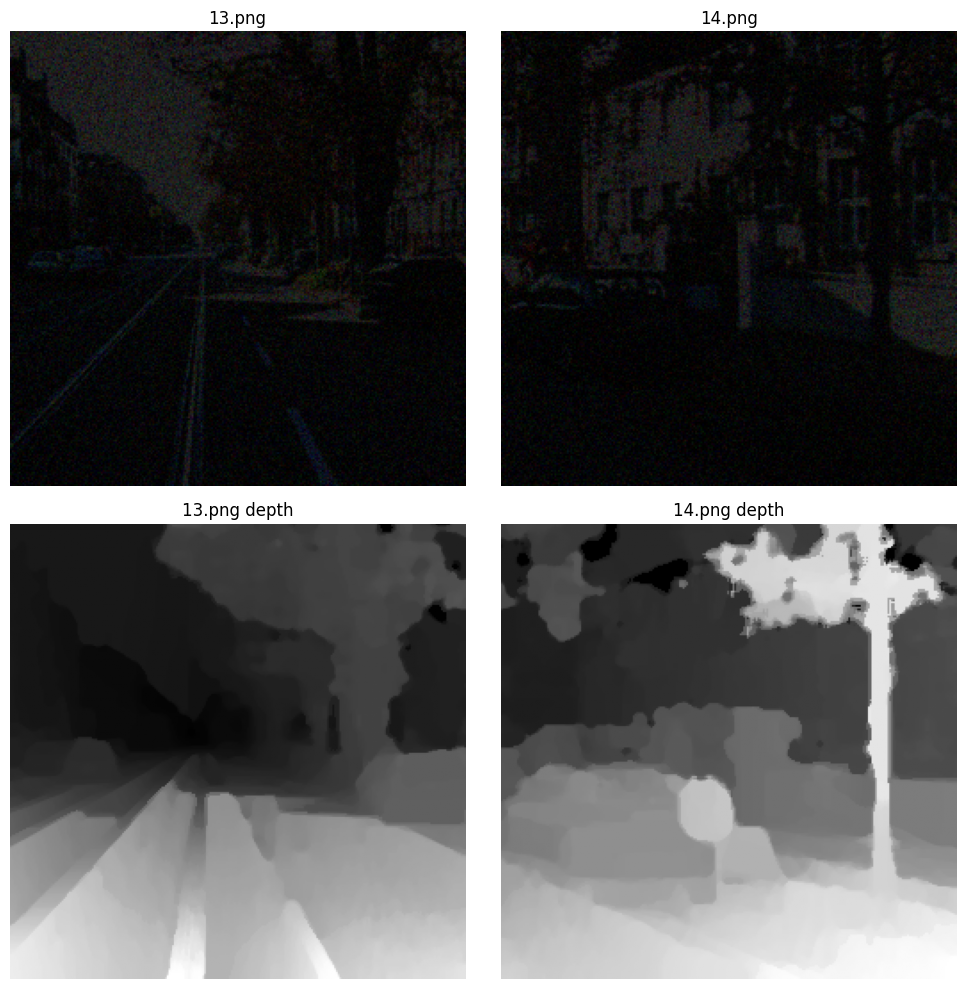

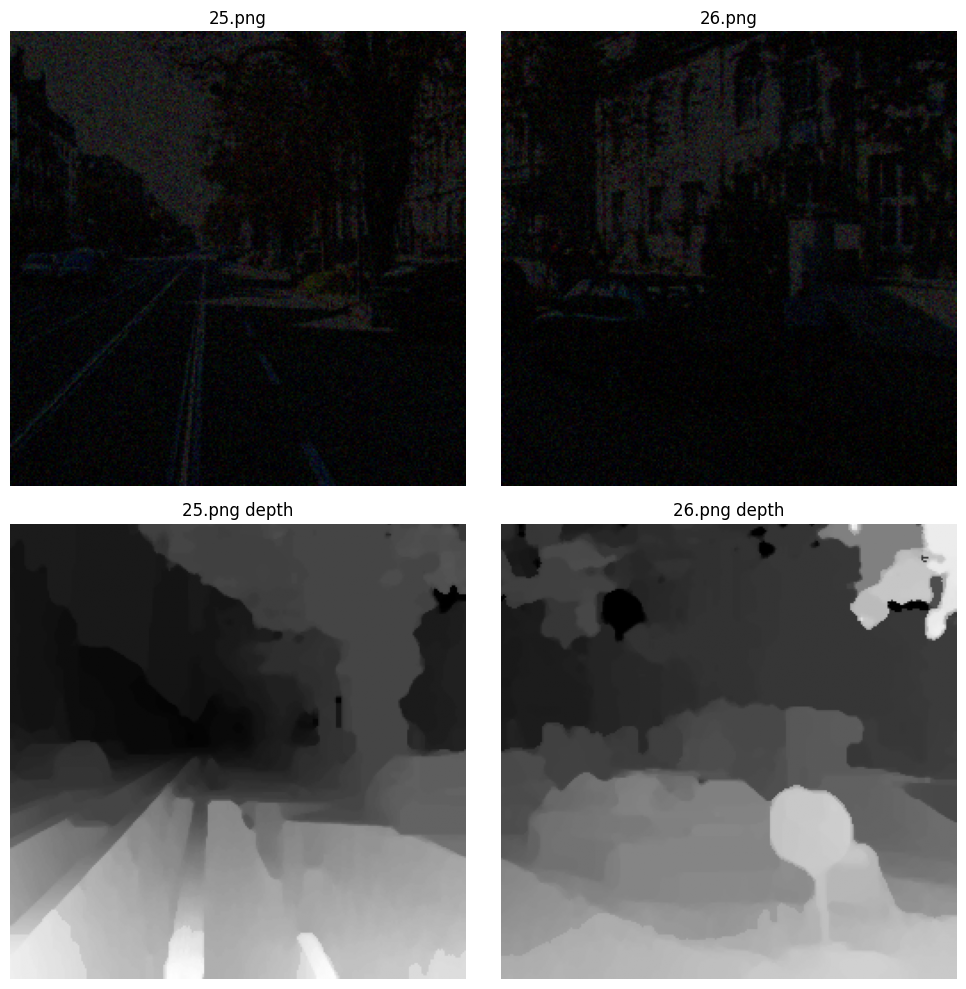

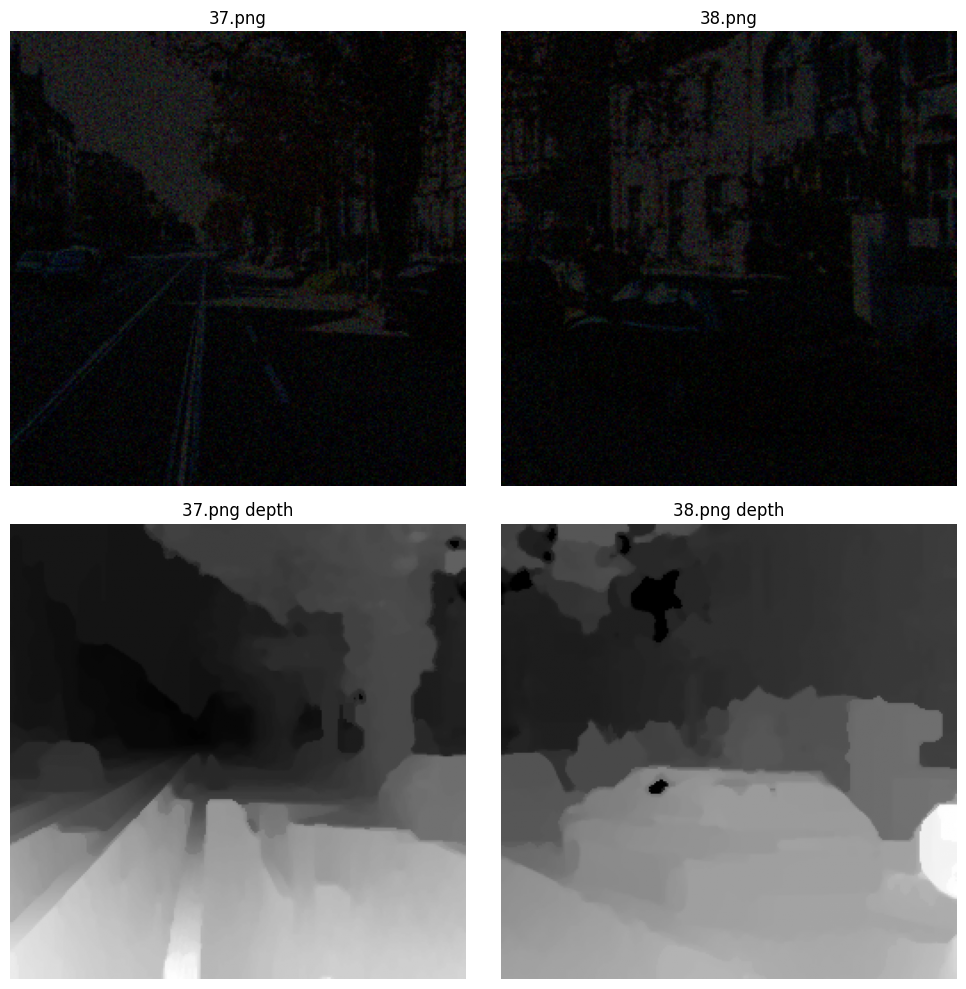

In [112]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

pairs_to_show = [
    ("13.png", "14.png"),
    ("25.png", "26.png"),
    ("37.png", "38.png"),
]

for f1, f2 in pairs_to_show:

    img1 = np.array(
        Image.open(
            TRAIN_IMG_DIR / f1
        )
    )

    img2 = np.array(
        Image.open(
            TRAIN_IMG_DIR / f2
        )
    )

    d1 = np.array(
        Image.open(
            TRAIN_DEPTH_DIR / f1
        )
    )

    d2 = np.array(
        Image.open(
            TRAIN_DEPTH_DIR / f2
        )
    )

    fig, axes = plt.subplots(
        2, 2,
        figsize=(10, 10)
    )

    axes[0,0].imshow(img1)
    axes[0,0].set_title(f1)

    axes[0,1].imshow(img2)
    axes[0,1].set_title(f2)

    axes[1,0].imshow(d1, cmap="gray")
    axes[1,0].set_title(
        f"{f1} depth"
    )

    axes[1,1].imshow(d2, cmap="gray")
    axes[1,1].set_title(
        f"{f2} depth"
    )

    for ax in axes.flat:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

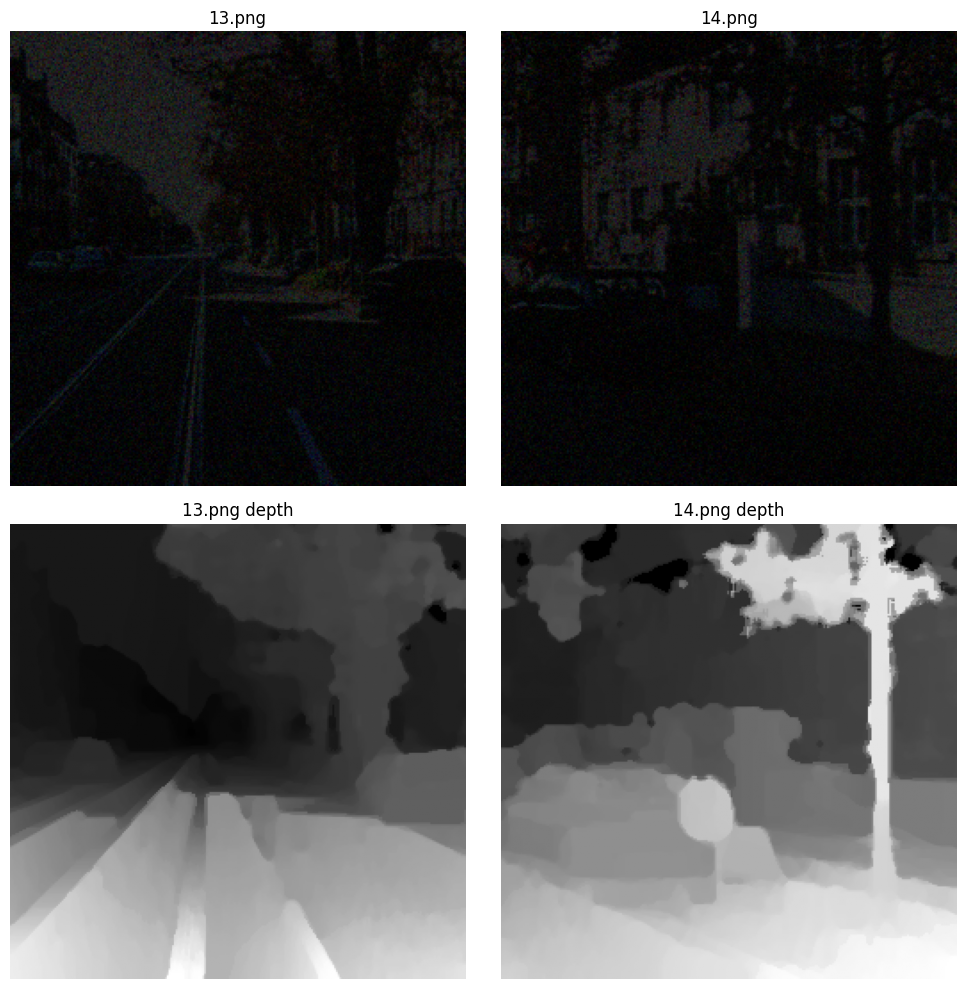

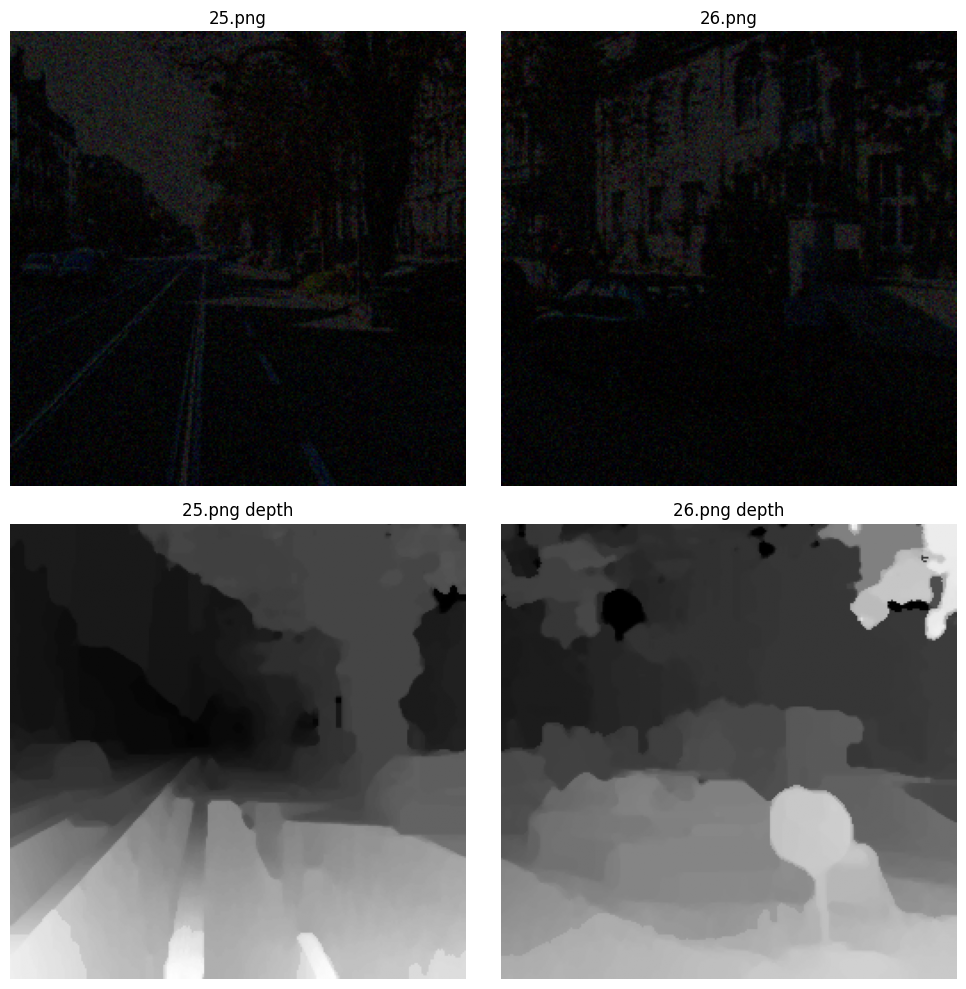

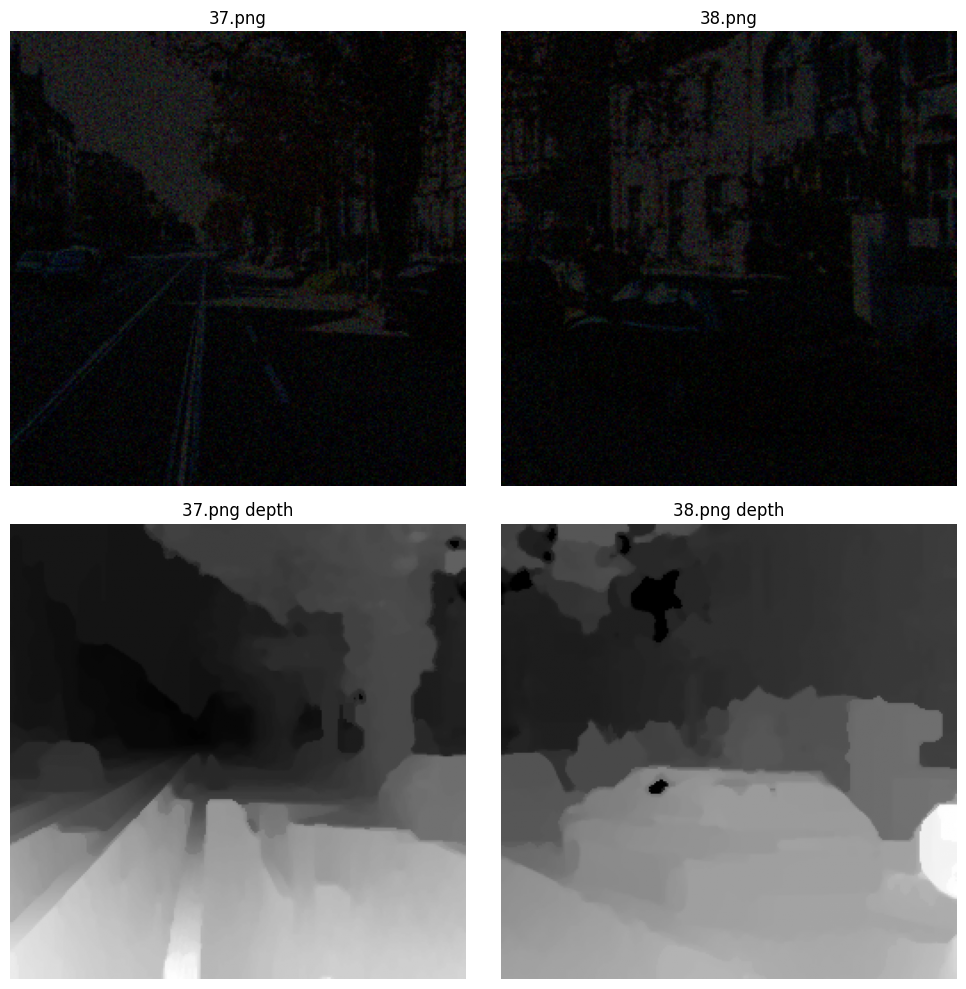

In [113]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

pairs_to_show = [
    ("13.png", "14.png"),
    ("25.png", "26.png"),
    ("37.png", "38.png"),
]

for f1, f2 in pairs_to_show:

    img1 = np.array(
        Image.open(
            TRAIN_IMG_DIR / f1
        )
    )

    img2 = np.array(
        Image.open(
            TRAIN_IMG_DIR / f2
        )
    )

    d1 = np.array(
        Image.open(
            TRAIN_DEPTH_DIR / f1
        )
    )

    d2 = np.array(
        Image.open(
            TRAIN_DEPTH_DIR / f2
        )
    )

    fig, axes = plt.subplots(
        2, 2,
        figsize=(10, 10)
    )

    axes[0,0].imshow(img1)
    axes[0,0].set_title(f1)

    axes[0,1].imshow(img2)
    axes[0,1].set_title(f2)

    axes[1,0].imshow(d1, cmap="gray")
    axes[1,0].set_title(
        f"{f1} depth"
    )

    axes[1,1].imshow(d2, cmap="gray")
    axes[1,1].set_title(
        f"{f2} depth"
    )

    for ax in axes.flat:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [114]:
for name, img_dir in [
    ("Validation", VAL_IMG_DIR),
    ("Test", TEST_IMG_DIR)
]:

    rows = []

    for p in Path(img_dir).glob("*.png"):

        image = np.array(
            Image.open(p).convert("RGB"),
            dtype=np.float32
        )

        rows.append({
            "filename": p.name,
            "last_digit": int(p.stem[-1]),
            "brightness": image.mean(),
            "rgb_std": image.std(),
            "rgb_max": image.max()
        })

    df = pd.DataFrame(rows)

    print(f"\n{name}")
    display(
        df.groupby("last_digit")[
            ["brightness", "rgb_std", "rgb_max"]
        ].agg(
            ["mean", "std", "min", "max"]
        )
    )


Validation


brightness                                   rgb_std            \
                 mean       std       min        max       mean       std   
last_digit                                                                  
1           11.461507  2.602714  3.510274  21.877054  11.624310  1.332808   
2            7.419381  2.958600  3.396693  18.146591   8.712523  2.448393   

                                   rgb_max                        
                 min        max       mean       std   min   max  
last_digit                                                        
1           5.041735  14.105397  69.122009  2.728646  58.0  77.0  
2           4.803304  14.400331  64.002396  7.752620  31.0  81.0


Test


brightness                                  rgb_std            \
                 mean       std      min        max       mean       std   
last_digit                                                                 
1           11.434083  2.580230  3.50971  21.139383  11.584705  1.318125   
2            7.465908  3.022174  3.38058  19.490366   8.720304  2.453353   

                                   rgb_max                        
                 min        max       mean       std   min   max  
last_digit                                                        
1           4.978165  13.838605  68.590912  2.975135  52.0  80.0  
2           4.781796  14.328514  62.980862  8.345054  31.0  79.0

In [115]:
from PIL import Image
import numpy as np
import pandas as pd
from pathlib import Path

rows = []

for p in Path(VAL_DEPTH_DIR).glob("*.png"):

    depth = np.array(
        Image.open(p),
        dtype=np.float32
    )

    rows.append({
        "filename": p.name,
        "last_digit": int(p.stem[-1]),
        "depth_mean": depth.mean(),
        "depth_std": depth.std(),
        "depth_min": depth.min(),
        "depth_max": depth.max(),
        "zero_pct": (
            (depth == 0).mean() * 100
        )
    })

val_depth_stats = pd.DataFrame(rows)

display(
    val_depth_stats
    .groupby("last_digit")[
        [
            "depth_mean",
            "depth_std",
            "depth_min",
            "depth_max",
            "zero_pct"
        ]
    ]
    .agg(["mean", "std", "min", "max"])
)

depth_mean                                  depth_std             \
                  mean        std       min        max       mean        std   
last_digit                                                                     
1            75.097466  14.035230  6.555023  148.93280  57.833054  11.191676   
2           100.914520  22.611673  7.676376  170.08844  54.569153  11.934707   

                                 depth_min                          depth_max  \
                 min        max       mean        std  min    max        mean   
last_digit                                                                      
1           8.705993  88.671928   6.057416   6.179688  0.0   72.0  211.117218   
2           4.627265  88.391228  17.985645  16.704363  0.0  123.0  235.552628   

                                    zero_pct                           
                  std   min    max      mean       std  min       max  
last_digit                                                             
1           36.227142  66.0  254.0  0.009049  0.164424  0.0  3.350830  
2           30.349733  18.0  255.0  0.001738  0.025027  0.0  0.430298